# Celda 0
instalación de dependencias y actualizacion de los paquetes (despues de iniciar esta celda es necesario reiniciar el entorno)

In [17]:
!pip install evaluate sacrebleu

  Using cached evaluate-0.4.6-py3-none-any.whl.metadata (9.5 kB)
  Using cached sacrebleu-2.6.0-py3-none-any.whl.metadata (39 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.8 MB/s eta 0:00:00


In [1]:
!pip install -q torch transformers datasets tokenizers evaluate accelerate seaborn matplotlib scikit-learn numpy sacrebleu zipfile urllib

!pip install --upgrade datasets torchvision transformers accelerate

ERROR: Could not find a version that satisfies the requirement zipfile (from versions: none)
ERROR: No matching distribution found for zipfile
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 70.4 MB/

# Celda 1 - Configuración del entorno

In [1]:
import torch
import transformers
import datasets
import random


if torch.cuda.is_available():
    # Crea un objeto 'device' que apunte a la GPU principal
    device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(0)
    print(f" Éxito: GPU detectada y configurada: {gpu_name}")
    print(f" Versión de CUDA disponible para PyTorch: {torch.version.cuda}")
else:

    print(" No se detectó una GPU ")
    device = torch.device("cpu")



# Limpia la caché de la GPU
# util en recompilacion, comentar si es primera vez

if device.type == 'cuda':
    torch.cuda.empty_cache()
    print(" Memoria de la GPU liberada y lista para trabajar.")


 Éxito: GPU detectada y configurada: Tesla T4
 Versión de CUDA disponible para PyTorch: 13.0
 Memoria de la GPU liberada y lista para trabajar.


#Celda 2.0: Descarga del corpus

In [2]:
import os
from datasets import Dataset
import urllib.request
import zipfile


url_corpus = "https://object.pouta.csc.fi/OPUS-CCMatrix/v1/moses/es-la.txt.zip"
ruta_zip = "./CCMatrix_es_la.zip"
directorio_extraccion = "./Raw_Data"

if not os.path.exists(ruta_zip):
  urllib.request.urlretrieve(url_corpus, ruta_zip)
else:
    print("Ya está descargado")

if not os.path.exists(directorio_extraccion):
    os.makedirs(directorio_extraccion)

with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall(directorio_extraccion)


ruta_es = "./Raw_Data/CCMatrix.es-la.es"
ruta_la = "./Raw_Data/CCMatrix.es-la.la"
ruta_scores = "./Raw_Data/CCMatrix.es-la.scores"

# Celda 2.1 Carga de datos y preprocesamiento

In [3]:

if all(os.path.exists(ruta) for ruta in [ruta_es, ruta_la, ruta_scores]):

    try:

        with open(ruta_es, 'r', encoding='utf-8') as f_es, \
             open(ruta_la, 'r', encoding='utf-8') as f_la, \
             open(ruta_scores, 'r', encoding='utf-8') as f_scores:

            # .strip() elimina los saltos de línea (\n) al final de cada oración
            textos_es = [linea.strip() for linea in f_es]
            textos_la = [linea.strip() for linea in f_la]
            # Convertimos los scores a números flotantes
            scores = [float(linea.strip()) for linea in f_scores]

        #  importante confirmar que el paralelismo es perfecto
        if not (len(textos_es) == len(textos_la) == len(scores)):
            raise ValueError("Los archivos no tienen la misma cantidad de líneas. El corpus está desalineado.")

        #  Construir el objeto Dataset de Hugging Face
        # Esto agrupa nuestras listas independientes en el formato optimizado que necesitamos
        dataset = Dataset.from_dict({
            "es": textos_es,
            "la": textos_la,
            "score": scores
        })

        print(f"\nDataset construido exitosamente desde los archivos paralelos :D ")
        print(f" Total de pares de oraciones disponibles en memoria: {len(dataset):,}")

        # muestreo
        print("\n 5 Pares de Oraciones Aleatorias")
        indices_aleatorios = random.sample(range(len(dataset)), 5)

        for i, idx in enumerate(indices_aleatorios):
            fila = dataset[idx]
            print(f"\n Ejemplo {i+1} (Índice {idx}):")
            print(f"    Latín:   {fila['la']}")
            print(f"    Español: {fila['es']}")
            print(f"    Score:   {fila['score']}")

    except Exception as e:
        print(f"\n error {e}")

else:
    print("la ruta esta incorrecta o faltan archivos")


Dataset construido exitosamente desde los archivos paralelos :D 
 Total de pares de oraciones disponibles en memoria: 587,701

 5 Pares de Oraciones Aleatorias

 Ejemplo 1 (Índice 296488):
    Latín:   Per trovare esattamente quello che cerchi procedi così:
    Español: Para identificar lo que quiere, haga esto:
    Score:   1.068301

 Ejemplo 2 (Índice 557351):
    Latín:   suam recepissent, aut plane destruxissem.
    Español: hospitales o aviones, desactive la alimentación.
    Score:   1.060623

 Ejemplo 3 (Índice 290246):
    Latín:   sunt vel pro-
    Español: Pero muy pro-
    Score:   1.0685717

 Ejemplo 4 (Índice 174310):
    Latín:   Notabiliter est, US habet 4.4% mundi multitudo, sed est scriptor advocatorum 70% of orbis terrarum et% 96 mundi habetis.
    Español: Tiene 4.4% de la población mundial, sin embargo, 70% de abogados y 96% de las demandas del mundo.
    Score:   1.0752189

 Ejemplo 5 (Índice 328076):
    Latín:   quo progrediare.
    Español: que progresar.
    S

# Celda 3: Filtrado de datos y limpieza

In [4]:
import re
import os


print("Iniciando el proceso de limpieza y filtrado del dataset...")

def limpiar_par_oraciones(fila):
    import re
    #importamos re adentro de la funcion porque windows no reconoce  el nucleo como global
    #solo para windows borrar si se usa en linux
#  hiperparámetros de impieza
    MIN_SCORE = 1.05
    MIN_PALABRAS = 3
    MAX_PALABRAS = 50
# Máxima desproporción permitida (ej. 2.0 significa que una oración
# no puede tener más del doble de palabras que su contraparte)
    MAX_PROPORCION = 2.0

    # Regla 1: Filtro de puntuación de alineación
    if fila['score'] < MIN_SCORE:
        return False

    #fix: agregamos un filtro de caracteres especiales antes de la longitud para eliminar casos obvios de ruido

    patron_permitido = r'[^a-zA-Z0-9áéíóúÁÉÍÓÚñÑüÜāēīōūĀĒĪŌŪ\s.,;:!?¿¡\'"()-]'

    texto_la = re.sub(patron_permitido, '', fila['la'])
    texto_es = re.sub(patron_permitido, '', fila['es'])

    if "http" in texto_la or "http" in texto_es or "<" in texto_la:
        return False

    texto_la = fila['la']
    texto_es = fila['es']

    #  filtro de caracteres
    if "http" in texto_la or "http" in texto_es or "<" in texto_la:
        return False

      # filtro de longitud
    palabras_la = texto_la.split()
    palabras_es = texto_es.split()

    len_la = len(palabras_la)
    len_es = len(palabras_es)

    if len_la < MIN_PALABRAS or len_la > MAX_PALABRAS:
        return False
    if len_es < MIN_PALABRAS or len_es > MAX_PALABRAS:
        return False


    proporcion = max(len_la, len_es) / min(len_la, len_es)
    if proporcion > MAX_PROPORCION:
        return False

    return True


# filtro con multiprocesamiento

num_nucleos = os.cpu_count() or 2
dataset_limpio = dataset.filter(limpiar_par_oraciones, num_proc=num_nucleos)

print(f" Pares originales: {len(dataset):,}")
print(f" Pares limpios retenidos: {len(dataset_limpio):,}")
print(f" Pares descartados: {len(dataset) - len(dataset_limpio):,}")

Iniciando el proceso de limpieza y filtrado del dataset...


Filter (num_proc=2):   0%|          | 0/587701 [00:00<?, ? examples/s]

 Pares originales: 587,701
 Pares limpios retenidos: 521,461
 Pares descartados: 66,240


# Celda 4: configuración del Tokenizador

In [5]:
from tokenizers import ByteLevelBPETokenizer
from transformers import PreTrainedTokenizerFast
import os


print("Iniciando la configuración del Tokenizador BPE Compartido...")

tokenizador = ByteLevelBPETokenizer()

# generador para alimentar los datos

def iterador_de_textos(dataset, tamaño_lote=1000):
    for i in range(0, len(dataset), tamaño_lote):
        # Extraemos un lote y combinamos las listas de español y latín
        lote = dataset[i : i + tamaño_lote]
        yield lote["la"] + lote["es"]

# hiperparms del tokenizador
TAMAÑO_VOCABULARIO = 32000
FRECUENCIA_MINIMA = 2
TOKENS_ESPECIALES = [
    "<pad>", # Padding (relleno para igualar longitudes)
    "<bos>", # Beginning of sequence (inicio de oración)
    "<eos>", # End of sequence (fin de oración)
    "<unk>"  # Unknown (palabra desconocida)
]



#  combinando ambos idiomas
tokenizador.train_from_iterator(
    iterador_de_textos(dataset_limpio),
    vocab_size=TAMAÑO_VOCABULARIO,
    min_frequency=FRECUENCIA_MINIMA,
    special_tokens=TOKENS_ESPECIALES
)

ruta_guardado = "./tokenizador_bpe_es_la"
if not os.path.exists(ruta_guardado):
    os.makedirs(ruta_guardado)

tokenizador.save(os.path.join(ruta_guardado, "tokenizer.json"))



Iniciando la configuración del Tokenizador BPE Compartido...


# Celda 5 Carga del Tokenizadory división Train/Val 90/10


In [6]:
import os
from transformers import PreTrainedTokenizerFast

print("Cargando el tokenizador entrenado y preparando las secuencias...")


def preparar_secuencias(lote):

    from transformers import PreTrainedTokenizerFast

    tokenizador_interno = PreTrainedTokenizerFast(
        tokenizer_file="./tokenizador_bpe_es_la/tokenizer.json",
        bos_token="<bos>",
        eos_token="<eos>",
        unk_token="<unk>",
        pad_token="<pad>"
    )

    LONGITUD_MAXIMA = 50

    inputs = tokenizador_interno(
        lote["la"],
        max_length=LONGITUD_MAXIMA,
        padding="max_length",
        truncation=True,
    )


    labels = tokenizador_interno(
        lote["es"],
        max_length=LONGITUD_MAXIMA,
        padding="max_length",
        truncation=True,
    )

    return {
        "input_ids": inputs["input_ids"],
        "attention_mask": inputs["attention_mask"],
        "labels": labels["input_ids"]
    }

print("Aplicando la tokenización a todo el dataset limpio (num_proc=12)...")


num_nucleos = os.cpu_count() or 2
dataset_tokenizado = dataset_limpio.map(
    preparar_secuencias,
    batched=True,
    num_proc=num_nucleos,
    remove_columns=["la", "es", "score"]
)
dataset_tokenizado.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

#  (90%) y Validación (10%)
print("\nRealizando la división del corpus (90% Train / 10% Validation)...")
dataset_final = dataset_tokenizado.train_test_split(test_size=0.1, seed=42)

print("\n¡Dataset tokenizado y dividido con éxito!")
print("Estado final de los datos listos para la red:")
print(f"Lotes de Entrenamiento: {len(dataset_final['train']):,}")
print(f"Lotes de Validación: {len(dataset_final['test']):,}")

Cargando el tokenizador entrenado y preparando las secuencias...
Aplicando la tokenización a todo el dataset limpio (num_proc=12)...


Map (num_proc=2):   0%|          | 0/521461 [00:00<?, ? examples/s]


Realizando la división del corpus (90% Train / 10% Validation)...

¡Dataset tokenizado y dividido con éxito!
Estado final de los datos listos para la red:
Lotes de Entrenamiento: 469,314
Lotes de Validación: 52,147


#Celda 6 Configuración del BART

In [7]:
import torch
from transformers import BartConfig, BartForConditionalGeneration, PreTrainedTokenizerFast



tokenizador_hf = PreTrainedTokenizerFast(
    tokenizer_file="./tokenizador_bpe_es_la/tokenizer.json",
    bos_token="<bos>",
    eos_token="<eos>",
    unk_token="<unk>",
    pad_token="<pad>"
)


configuracion = BartConfig(
    vocab_size=32000,           # Debe coincidir exactamente con el tokenizador de la Celda 4
    d_model=512,                # Dimensión de los vectores
    encoder_layers=6,           # Número de capas del codificador
    decoder_layers=4,           # Número de capas del decodificador
    encoder_attention_heads=8,  # Cabezales de atención paralela
    decoder_attention_heads=8,
    encoder_ffn_dim=1024,       # Tamaño de la red feed-forward interna
    decoder_ffn_dim=1024,
    max_position_embeddings=50, # Límite de la secuencia
    pad_token_id=tokenizador_hf.pad_token_id,
    bos_token_id=tokenizador_hf.bos_token_id,
    eos_token_id=tokenizador_hf.eos_token_id,
    forced_eos_token_id=tokenizador_hf.eos_token_id,
)


modelo = BartForConditionalGeneration(configuracion)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo = modelo.to(device)

total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"Total de parámetros a entrenar: {total_params:,}")

Total de parámetros a entrenar: 41,673,728


# Celda 7: Configuración de los Hiperparámetros

In [10]:
import numpy as np
from transformers import Seq2SeqTrainingArguments

print("Configurando los hiperparámetros")

def calcular_metricas_convergencia(eval_pred):
    import numpy as np
    predicciones, etiquetas = eval_pred

    if isinstance(predicciones, tuple):
        logits = predicciones[0]
    else:
        logits = predicciones

    etiquetas = np.where(etiquetas != -100, etiquetas, 0)
    return {}


argumentos_entrenamiento = Seq2SeqTrainingArguments(
    output_dir="./modelo_latin_espanol",


    learning_rate=1e-4,
    warmup_steps=500,               # Calentamiento adaptativo para proteger pesos iniciales aleatorios
    label_smoothing_factor=0.1,      # Suavizado contra ruido y paráfrasis de CCMatrix
    optim="adamw_torch",

    per_device_train_batch_size=251,
    per_device_eval_batch_size=251,
    gradient_accumulation_steps=1,
    fp16=True,
    dataloader_num_workers=4,


    eval_strategy="steps",
    eval_steps=500,                 # Frecuencia de evaluación intermedia
    save_strategy="steps",
    save_steps=500,
    load_best_model_at_end=True,     # Recupera automáticamente el punto exacto con menor pérdida
    metric_for_best_model="loss",
    greater_is_better=False,         # Un valor menor de pérdida indica mejor traducción

    # Configuración de Inferencia en Validación
    predict_with_generate=True,      # Activa la generación real por búsqueda de haz
    report_to="none"
)


Configurando los hiperparámetros


# Celda Limpieza GPU pre entrenamiento (Opcional, usar si la gpu manda CUDA OUT OF MEMORY ERROR)

In [12]:
import torch
import gc

print(f"Memoria reservada antes de limpiar: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")


try:
    del entrenador
    del resultados_entrenamiento

except NameError:
    pass

gc.collect()

torch.cuda.empty_cache()

print(f"Memoria reservada después de limpiar: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")

Memoria reservada antes de limpiar: 13.14 GB
Memoria reservada después de limpiar: 4.63 GB


# **Celda 8: Entrenamiento del Modelo**

In [13]:
from transformers import Seq2SeqTrainer, DataCollatorForSeq2Seq, PreTrainedTokenizerFast

print("Preparando el motor de entrenamiento...")

# recargar el tokenizador en el entorno global por lo de windows
tokenizador_hf = PreTrainedTokenizerFast(
    tokenizer_file="./tokenizador_bpe_es_la/tokenizer.json",
    bos_token="<bos>",
    eos_token="<eos>",
    unk_token="<unk>",
    pad_token="<pad>"
)

#  Data Collator para tareas Seq2Seq
data_collator = DataCollatorForSeq2Seq(
    tokenizador_hf,
    model=modelo
)

dataset_final.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# Trainer de Hugging Face
entrenador = Seq2SeqTrainer(
    model=modelo,                             # La arquitectura definida en la Celda 6
    args=argumentos_entrenamiento,            # Las reglas y optimizaciones de la Celda 7
    train_dataset=dataset_final["train"],     # El 90% de los datos para aprender
    eval_dataset=dataset_final["test"],       # El 10% de los datos para examinarse
    data_collator=data_collator,              # El empaquetador de matrices
    compute_metrics=calcular_metricas_convergencia, # Nuestra función de métricas
    processing_class=tokenizador_hf          # REEMPLAZO: Palabra clave moderna que corrige el TypeError
)


#  bucle de entrenamiento
dataset_final.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
resultados_entrenamiento = entrenador.train()



ruta_modelo_final = "./modelo_latin_espanol_final"
entrenador.save_model(ruta_modelo_final)


print(f"El modelo  guardado en: {ruta_modelo_final}")

Preparando el motor de entrenamiento...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:430: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/tr

Step,Training Loss,Validation Loss
500,6.264498,2.668470
1000,2.555623,2.470840
1500,2.442132,2.398561
2000,2.380142,2.351526
2500,2.334061,2.316930
3000,2.308526,2.290400
3500,2.286626,2.269338
4000,2.261253,2.254115
4500,2.242004,2.243571
5000,2.231494,2.236250


/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:600: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)
/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:600: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)
/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:600: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please conside

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:430: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/tr

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

El modelo  guardado en: ./modelo_latin_espanol_final


# Celda 9: Carga del modelo, configuración de generacion y test


In [15]:
import torch
from transformers import BartForConditionalGeneration, PreTrainedTokenizerFast

print("Cargando el modelo final desde el disco y preparando la interfaz de traducción...")

# Cargar el tokenizador y el modelo final (Seguro para Windows y reinicios de kernel)
ruta_modelo = "./modelo_latin_espanol_final"
ruta_tokenizador = "./tokenizador_bpe_es_la/tokenizer.json"

tokenizador_inf = PreTrainedTokenizerFast(
    tokenizer_file=ruta_tokenizador,
    bos_token="<bos>",
    eos_token="<eos>",
    unk_token="<unk>",
    pad_token="<pad>"
)

# Cargamos la arquitectura con los pesos definitivos aprendidos por la GPU
modelo_inf = BartForConditionalGeneration.from_pretrained(ruta_modelo)

#  Transferir a la GPU y establecer el modo de evaluación
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo_inf = modelo_inf.to(device)

# Cambia el comportamiento matemático de la red de "aprender" a "predecir"
modelo_inf.eval()

#  Definición de la función de inferencia
def traducir_latin_a_espanol(texto_latin):
    # Convertir el texto a tensores de PyTorch
    inputs = tokenizador_inf(
        texto_latin,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=40
    ).to(device)


    with torch.no_grad():
        outputs = modelo_inf.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=40,
            max_length=None,
            num_beams=5,
            length_penalty=1.2,       #  < 1.0 a oraciones concisas y no sienta la necesidad de rellenar.
            no_repeat_ngram_size=2,   #  Anti Tartamudeo
            repetition_penalty=1.5,   # cuando el valor es muy alto, empieza a escupir simbolos porque en el intento de no repetir palabras pone simbolos, cuando es muy bajo empieza a tartamudear, a decir "noche noche noche noche"
            early_stopping=True
        )

    traduccion = tokenizador_inf.decode(outputs[0], skip_special_tokens=True)
    traduccion = traduccion.replace('Ġ', ' ').replace('<pad>', '').strip()
    traduccion = re.sub(r'[^a-zA-ZáéíóúÁÉÍÓÚñÑüÜ0-9\s.,!?;:-]', '', traduccion)
    traduccion = re.sub(r'\s+', ' ', traduccion)
    traduccion = re.sub(r'\s([.,!?;:])', r'\1', traduccion)
    traduccion = re.sub(r'\.{2,}', '.', traduccion)
    traduccion = re.sub(r'^([.,!?;:])+', '', traduccion)

    return traduccion.strip()
    return traduccion

print("\nMotor de inferencia listo.")
print("Probando el modelo con una frase de ejemplo...")

# Prueba
frase_prueba = input("\nIngrese una frase en latín para traducir al español: ")
traduccion_prueba = traducir_latin_a_espanol(frase_prueba)
print(f"\nLatín: {frase_prueba}")
print(f"Español: {traduccion_prueba}")

Cargando el modelo final desde el disco y preparando la interfaz de traducción...


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]


Motor de inferencia listo.
Probando el modelo con una frase de ejemplo...

Ingrese una frase en latín para traducir al español: Pater noster qui es in caelis, sanctificetur nomen tuum. Adveniat regnum tuum. Fiat voluntas tua, sicut in caelo et in terra.

Latín: Pater noster qui es in caelis, sanctificetur nomen tuum. Adveniat regnum tuum. Fiat voluntas tua, sicut in caelo et in terra.
Español: Su padre es el que está en el nombre de tu nombre, y su nombre será tu reino, como la voluntad en la tierra y como como en tu tierra.


# Celda 10: evaluación BLEU

In [18]:
#bleu 2 test
import math
import evaluate
from tqdm.auto import tqdm


resultados_eval = entrenador.evaluate()
perdida_eval = resultados_eval.get("eval_loss", 0.0)
perplejidad = math.exp(perdida_eval) if perdida_eval > 0 else float('inf')


print(f"Pérdida de Validación: {perdida_eval:.4f}")
print(f"Perplejidad: {perplejidad:.4f}")


metrica_bleu = evaluate.load("sacrebleu")

tamano_muestra = min(50, len(dataset_final["test"]))




muestra_test = dataset_final["test"].shuffle(seed=9).select(range(tamano_muestra))



predicciones_es = []
referencias_es = []

print("\n5 ejemplos de como esta funcionando BLEU internamente")

for i in tqdm(range(tamano_muestra), desc="Generando..."):
    # Decodificación estricta saltando special tokens
    texto_lat = tokenizador_inf.decode(muestra_test[i]["input_ids"], skip_special_tokens=True)
    referencia_humana = tokenizador_inf.decode(muestra_test[i]["labels"], skip_special_tokens=True)

    prediccion_maquina = traducir_latin_a_espanol(texto_lat)

    # Limpieza manual de artefactos BPE por si skip_special_tokens falla
    prediccion_maquina = prediccion_maquina.replace('Ġ', ' ').replace('<pad>', '').strip()

    predicciones_es.append(prediccion_maquina)
    referencias_es.append([referencia_humana])

    if i < 5:
        print(f"\nEjemplo {i+1}:")
        print(f"Latín (Input):   {texto_lat}")
        print(f"Máquina (Pred):  {prediccion_maquina}")
        print(f"Humano (Ref):    {referencia_humana}")


#  BLEU
resultados_bleu = metrica_bleu.compute(predictions=predicciones_es, references=referencias_es)

print(f"Puntuación BLEU: {resultados_bleu['score']:.2f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:430: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/tr

Training Loss,Validation Loss,Step
2.229179,2.232469,5610


Pérdida de Validación: 2.2325
Perplejidad: 9.3229


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



5 ejemplos de como esta funcionando BLEU internamente


Generando...:   0%|          | 0/50 [00:00<?, ?it/s]


Ejemplo 1:
Latín (Input):   Cum at alterum maiestatis interesset.
Máquina (Pred):  Y como se ha de acuerdo con él. que se han sido entre ellos mismos mismos,. un
Humano (Ref):    Avda Miterrant con los grandes modistos.

Ejemplo 2:
Latín (Input):   quae ille monstra, di immortales ?
Máquina (Pred):  Qué es la verdad de los inmortales?.,. el. que lo
Humano (Ref):    Pero, ¿quiénes son esos inmortales?

Ejemplo 3:
Latín (Input):   totam ut per vitam servetur parva puella.
Máquina (Pred):  La vida de la vida es una chica chica muy buena niña., que. yo
Humano (Ref):    Vaya tostón me ha soltado la pobre chica.

Ejemplo 4:
Latín (Input):   «La plus belle des ruses du diable est de vous persuader qu'il n'existe pas.»
Máquina (Pred):  El más grande del diablo es que el diablo no tiene nada de creer que no existe.
Humano (Ref):    "Una de las mejores cosas que hizo el Diablo es convencer a la gente de que no existe."

Ejemplo 5:
Latín (Input):   Per veritatem [142] Deus qui non mentitur et no

#Celda 9.1 (codigo Repetido para experimento)

In [19]:
#Es la misma celda sin el Test, se usa para pruebas más rapidas

import re
import torch

def traducir_latin_a_espanol(texto_latin):
    inputs = tokenizador_inf(
        texto_latin,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=40
    ).to(device)

    with torch.no_grad():
        outputs = modelo_inf.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=40,
            max_length=None,
            num_beams=5,
        )

    traduccion = tokenizador_inf.decode(outputs[0], skip_special_tokens=True)
    traduccion = traduccion.replace('Ġ', ' ').replace('<pad>', '').strip()
    traduccion = re.sub(r'[^a-zA-ZáéíóúÁÉÍÓÚñÑüÜ0-9\s.,!?;:-]', '', traduccion)
    traduccion = re.sub(r'\s+', ' ', traduccion)
    traduccion = re.sub(r'\s([.,!?;:])', r'\1', traduccion)
    traduccion = re.sub(r'\.{2,}', '.', traduccion)
    traduccion = re.sub(r'^([.,!?;:])+', '', traduccion)

    return traduccion.strip()

print("Motor de traducción calibrado")

Motor de traducción calibrado


# Celda 10.1 Comprobación BLEU con los valores del experimento


In [20]:
import math
import evaluate
from tqdm.auto import tqdm


resultados_eval = entrenador.evaluate()
perdida_eval = resultados_eval.get("eval_loss", 0.0)
perplejidad = math.exp(perdida_eval) if perdida_eval > 0 else float('inf')


print(f"Pérdida de Validación: {perdida_eval:.4f}")
print(f"Perplejidad: {perplejidad:.4f}")


metrica_bleu = evaluate.load("sacrebleu")

tamano_muestra = min(50, len(dataset_final["test"]))




muestra_test = dataset_final["test"].shuffle(seed=9).select(range(tamano_muestra))



predicciones_es = []
referencias_es = []

print("\n5 ejemplos de como esta funcionando BLEU internamente")

for i in tqdm(range(tamano_muestra), desc="Generando..."):

    texto_lat = tokenizador_inf.decode(muestra_test[i]["input_ids"], skip_special_tokens=True)
    referencia_humana = tokenizador_inf.decode(muestra_test[i]["labels"], skip_special_tokens=True)

    prediccion_maquina = traducir_latin_a_espanol(texto_lat)

    prediccion_maquina = prediccion_maquina.replace('Ġ', ' ').replace('<pad>', '').strip()

    predicciones_es.append(prediccion_maquina)
    referencias_es.append([referencia_humana])

    if i < 5:
        print(f"\nEjemplo {i+1}:")
        print(f"Latín (Input):   {texto_lat}")
        print(f"Máquina (Pred):  {prediccion_maquina}")
        print(f"Humano (Ref):    {referencia_humana}")


#  BLEU
resultados_bleu = metrica_bleu.compute(predictions=predicciones_es, references=referencias_es)

print(f"Puntuación BLEU: {resultados_bleu['score']:.2f}")

/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:600: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)
/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:600: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)
/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:600: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please conside

Training Loss,Validation Loss,Step
2.229179,2.232469,5610


Pérdida de Validación: 2.2325
Perplejidad: 9.3229

5 ejemplos de como esta funcionando BLEU internamente


Generando...:   0%|          | 0/50 [00:00<?, ?it/s]


Ejemplo 1:
Latín (Input):   Cum at alterum maiestatis interesset.
Máquina (Pred):  Como se puede ser un poco.
Humano (Ref):    Avda Miterrant con los grandes modistos.

Ejemplo 2:
Latín (Input):   quae ille monstra, di immortales ?
Máquina (Pred):  Qué son los inmortales?
Humano (Ref):    Pero, ¿quiénes son esos inmortales?

Ejemplo 3:
Latín (Input):   totam ut per vitam servetur parva puella.
Máquina (Pred):  La vida es una buena chica.
Humano (Ref):    Vaya tostón me ha soltado la pobre chica.

Ejemplo 4:
Latín (Input):   «La plus belle des ruses du diable est de vous persuader qu'il n'existe pas.»
Máquina (Pred):  El más grande del diablo es que el diablo es que no existe.
Humano (Ref):    "Una de las mejores cosas que hizo el Diablo es convencer a la gente de que no existe."

Ejemplo 5:
Latín (Input):   Per veritatem [142] Deus qui non mentitur et non est inventus dolus in ore eius.
Máquina (Pred):  Por lo tanto, no hay nada que Allah, no es un dios de Allah.
Humano (Ref):    Alla

#Celda 11 Graficación Mapa de Atención Cruzada

Buscando los identificadores de los tokens en el vocabulario BPE...
Reduciendo dimensiones con PCA para graficar en 2D...


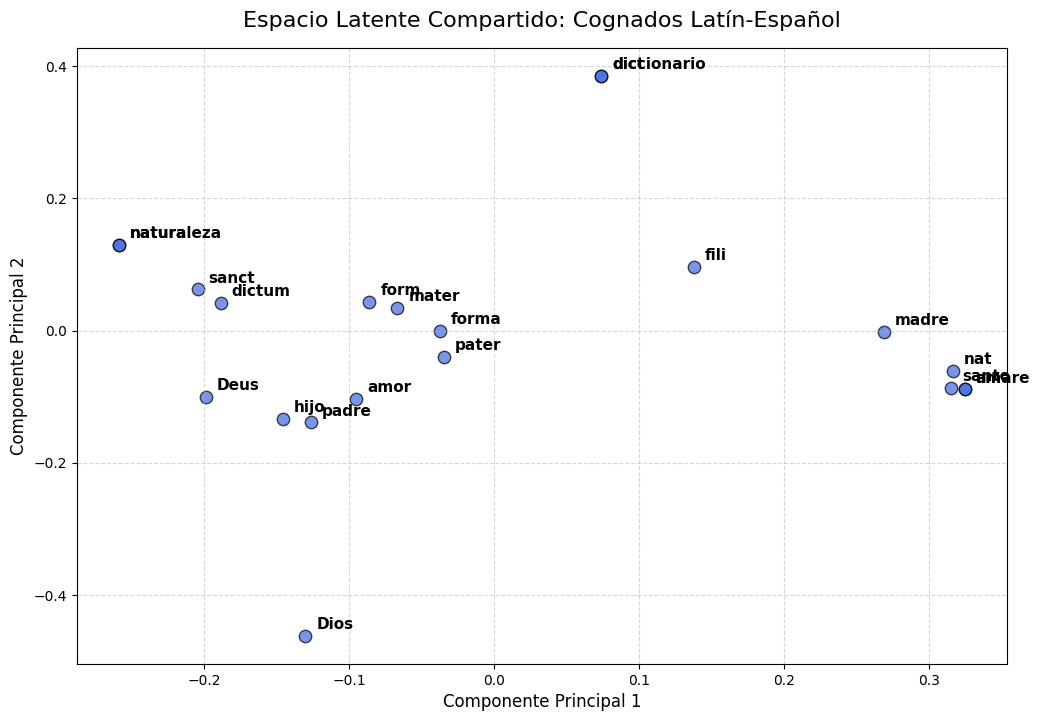

In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

matriz_embeddings = modelo_inf.get_input_embeddings().weight.detach().cpu().numpy()

#  Definir un conjunto de raíces y cognados para analizar
palabras_interes = [
    "Deus", "Dios",
    "am", "amor", "amare",
    "nat", "naturaleza", "natura",
    "dict", "diccionario", "dictum",
    "form", "forma",
    "pater", "padre",
    "mater", "madre",
    "fili", "hijo",
    "sanct", "santo"
]

ids_interes = []
etiquetas_encontradas = []

print("Buscando los identificadores de los tokens en el vocabulario BPE...")

# Buscar los IDs numéricos de estas palabras en nuestro tokenizador
for palabra in palabras_interes:
    tokens = tokenizador_inf.encode(palabra, add_special_tokens=False)
    if len(tokens) > 0:
        ids_interes.append(tokens[0])
        etiquetas_encontradas.append(palabra)


vectores_interes = matriz_embeddings[ids_interes]


print("Reduciendo dimensiones con PCA para graficar en 2D...")
pca = PCA(n_components=2)
vectores_2d = pca.fit_transform(vectores_interes)

plt.figure(figsize=(12, 8))
plt.scatter(vectores_2d[:, 0], vectores_2d[:, 1], color='royalblue', edgecolors='black', s=80, alpha=0.7)

for i, etiqueta in enumerate(etiquetas_encontradas):
    plt.annotate(
        etiqueta,
        (vectores_2d[i, 0], vectores_2d[i, 1]),
        xytext=(8, 5),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Espacio Latente Compartido: Cognados Latín-Español", fontsize=16, pad=15)
plt.xlabel("Componente Principal 1", fontsize=12)
plt.ylabel("Componente Principal 2", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)


plt.show()

# Celda 12: Analisis visual curvas de convergencia

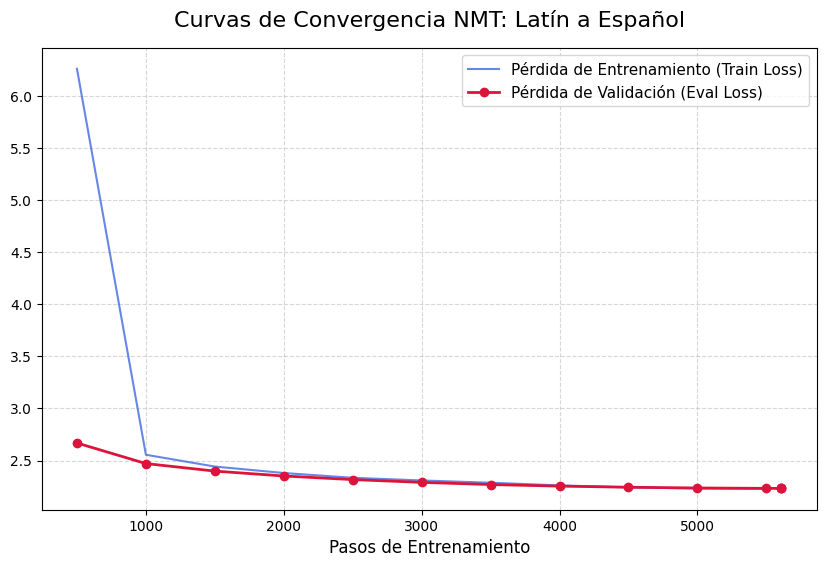

[transformers] `sdpa` attention does not support `output_attentions=True`. Please set your attention to `eager` if you want any of these features.
[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Nota: Tu arquitectura específica no devolvió 'cross_attentions'. Detalle técnico: tuple index out of range


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch


try:

    historial = entrenador.state.log_history

    pasos_train = []
    loss_train = []
    pasos_eval = []
    loss_eval = []

    for log in historial:
        if 'loss' in log and 'step' in log:
            pasos_train.append(log['step'])
            loss_train.append(log['loss'])
        elif 'eval_loss' in log and 'step' in log:
            pasos_eval.append(log['step'])
            loss_eval.append(log['eval_loss'])

    plt.figure(figsize=(10, 6))
    if loss_train:
        plt.plot(pasos_train, loss_train, label='Pérdida de Entrenamiento (Train Loss)', color='royalblue', alpha=0.8)
    if loss_eval:
        plt.plot(pasos_eval, loss_eval, label='Pérdida de Validación (Eval Loss)', color='crimson', marker='o', linewidth=2)

    plt.title('Curvas de Convergencia NMT: Latín a Español', fontsize=16, pad=15)
    plt.xlabel('Pasos de Entrenamiento', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

except NameError:
    print(" ya no está en memoria. ")


frase_atencion = "Alea iacta est."

inputs = tokenizador_inf(frase_atencion, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = modelo_inf.generate(
        inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=20,
        num_beams=1,
        output_attentions=True,
        return_dict_in_generate=True

    )


tokens_latin = tokenizador_inf.convert_ids_to_tokens(inputs["input_ids"][0])
tokens_espanol = tokenizador_inf.convert_ids_to_tokens(outputs.sequences[0])

# Limpiamos el marcador  ('Ġ' o espacios) para que la gráfica se lea bien
tokens_latin = [t.replace('Ġ', '').replace(' ', '') for t in tokens_latin]
tokens_espanol = [t.replace('Ġ', '').replace(' ', '') for t in tokens_espanol]

try:

    atenciones = outputs.cross_attentions


    matriz_atencion = np.zeros((len(tokens_espanol) - 1, len(tokens_latin)))


    for i, tupla_atencion_paso in enumerate(atenciones):
        capa_final = tupla_atencion_paso[-1][0]
        # Promedio el enfoque de los 8 cabezales de atención
        promedio_cabezales = capa_final.mean(dim=0).squeeze().cpu().numpy()
        matriz_atencion[i] = promedio_cabezales


    plt.figure(figsize=(10, 8))
    sns.heatmap(matriz_atencion,
                xticklabels=tokens_latin,
                yticklabels=tokens_espanol[1:],
                cmap="mako",
                annot=True,
                fmt=".2f",
                cbar_kws={'label': 'Peso de Atención'})

    plt.title('Mecanismo de Autoatención: Alineación Latín-Español', fontsize=16, pad=15)
    plt.xlabel('Texto de Origen (Latín)', fontsize=12, fontweight='bold')
    plt.ylabel('Texto Generado (Español)', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.show()

except Exception as e:
    print(f"Nota: Tu arquitectura específica no devolvió 'cross_attentions'. Detalle técnico: {e}")

#Celda 13 Gráfica Control de probabilidades (softmax con temperatura)

Temperatura en la capa Softmax


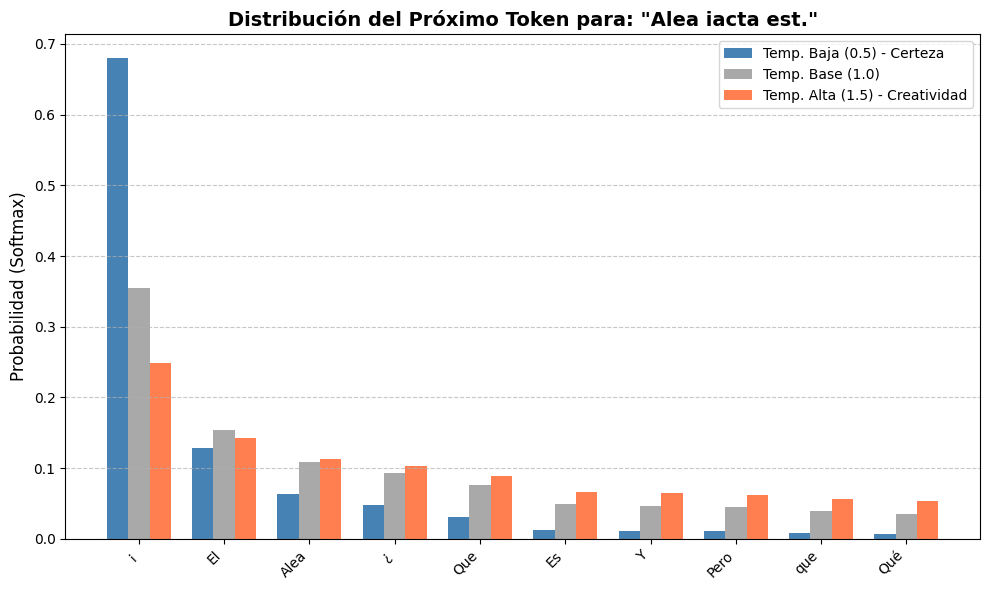

In [23]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

print("Temperatura en la capa Softmax")

def analizar_temperatura(frase_ejemplo, temp_baja=0.5, temp_alta=1.5):
    inputs = tokenizador_inf(frase_ejemplo, return_tensors="pt").to(device)

    with torch.no_grad():
        # Ejecutamos solo una pasada por el codificador y el primer paso del decodificador
        # Forzamos al modelo a pensar en el inicio de la oración usando el token <bos>
        decoder_input_ids = torch.tensor([[modelo_inf.config.decoder_start_token_id]]).to(device)

        salida = modelo_inf(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            decoder_input_ids=decoder_input_ids
        )

    logits_crudos = salida.logits[0, -1, :]


    top_k = 10
    valores_top_k, indices_top_k = torch.topk(logits_crudos, top_k)

    # 1. Softmax Original (Temperatura = 1.0)
    prob_original = F.softmax(valores_top_k, dim=0).cpu().numpy()

    # 2. Softmax greedy
    prob_baja = F.softmax(valores_top_k / temp_baja, dim=0).cpu().numpy()

    # 3. Softmax creativo
    prob_alta = F.softmax(valores_top_k / temp_alta, dim=0).cpu().numpy()

    tokens_candidatos = [tokenizador_inf.decode([idx]).strip() for idx in indices_top_k.cpu().numpy()]

    # Graficar
    fig, ax = plt.subplots(figsize=(10, 6))
    indices = np.arange(top_k)
    ancho = 0.25

    ax.bar(indices - ancho, prob_baja, ancho, label=f'Temp. Baja ({temp_baja}) - Certeza', color='steelblue')
    ax.bar(indices, prob_original, ancho, label='Temp. Base (1.0)', color='darkgray')
    ax.bar(indices + ancho, prob_alta, ancho, label=f'Temp. Alta ({temp_alta}) - Creatividad', color='coral')

    ax.set_ylabel('Probabilidad (Softmax)', fontsize=12)
    ax.set_title(f'Distribución del Próximo Token para: "{frase_ejemplo}"', fontsize=14, fontweight='bold')
    ax.set_xticks(indices)
    ax.set_xticklabels(tokens_candidatos, rotation=45, ha='right')
    ax.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

analizar_temperatura("Alea iacta est.")

# Celda 14 Visualización de PCA de Embeddings (POST ENTRENAMIENTO)

 Espacio Latente (Embeddings)


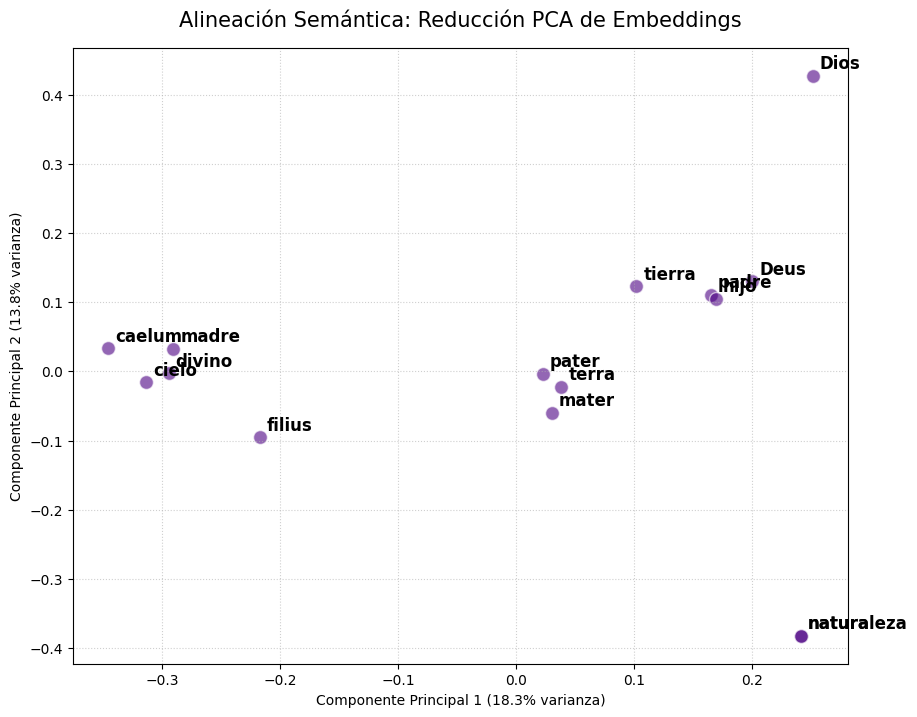

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print(" Espacio Latente (Embeddings)")

def graficar_pca_embeddings(palabras_interes):
    # 1. Obtener la matriz gigante de Embeddings de entrada
    matriz_embeddings = modelo_inf.get_input_embeddings().weight.detach().cpu().numpy()

    ids_interes = []
    etiquetas_validas = []

    # 2. Buscar los IDs de las palabras en el tokenizador
    for palabra in palabras_interes:
        # Codificamos sin los tokens especiales <bos> y <eos>
        tokens = tokenizador_inf.encode(palabra, add_special_tokens=False)
        if len(tokens) > 0:
            ids_interes.append(tokens[0]) # Tomamos el ID de la raíz principal
            etiquetas_validas.append(palabra)

    # 3. Extraer solo los vectores matemáticos de esas palabras
    vectores = matriz_embeddings[ids_interes]

    # 4. Reducción de Dimensionalidad (PCA de d_model a 2D)
    pca = PCA(n_components=2)
    vectores_2d = pca.fit_transform(vectores)

    # 5. Graficar
    plt.figure(figsize=(10, 8))
    plt.scatter(vectores_2d[:, 0], vectores_2d[:, 1], color='indigo', s=100, alpha=0.6, edgecolors='w')

    # Anotaciones
    for i, etiqueta in enumerate(etiquetas_validas):
        plt.annotate(
            etiqueta,
            (vectores_2d[i, 0], vectores_2d[i, 1]),
            xytext=(5, 5), textcoords='offset points',
            fontsize=12, fontweight='bold'
        )

    plt.title("Alineación Semántica: Reducción PCA de Embeddings", fontsize=15, pad=15)
    plt.xlabel(f"Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)")
    plt.ylabel(f"Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# Proporcionamos pares de palabras equivalentes o relacionadas
pares_latin_espanol = [
    "Deus", "Dios", "divino",
    "pater", "padre",
    "mater", "madre",
    "filius", "hijo",
    "terra", "tierra",
    "caelum", "cielo",
    "natura", "naturaleza"
]

graficar_pca_embeddings(pares_latin_espanol)

# Celda 15 Mapa de Calor de Pesos

[transformers] Both `max_new_tokens` (=40) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


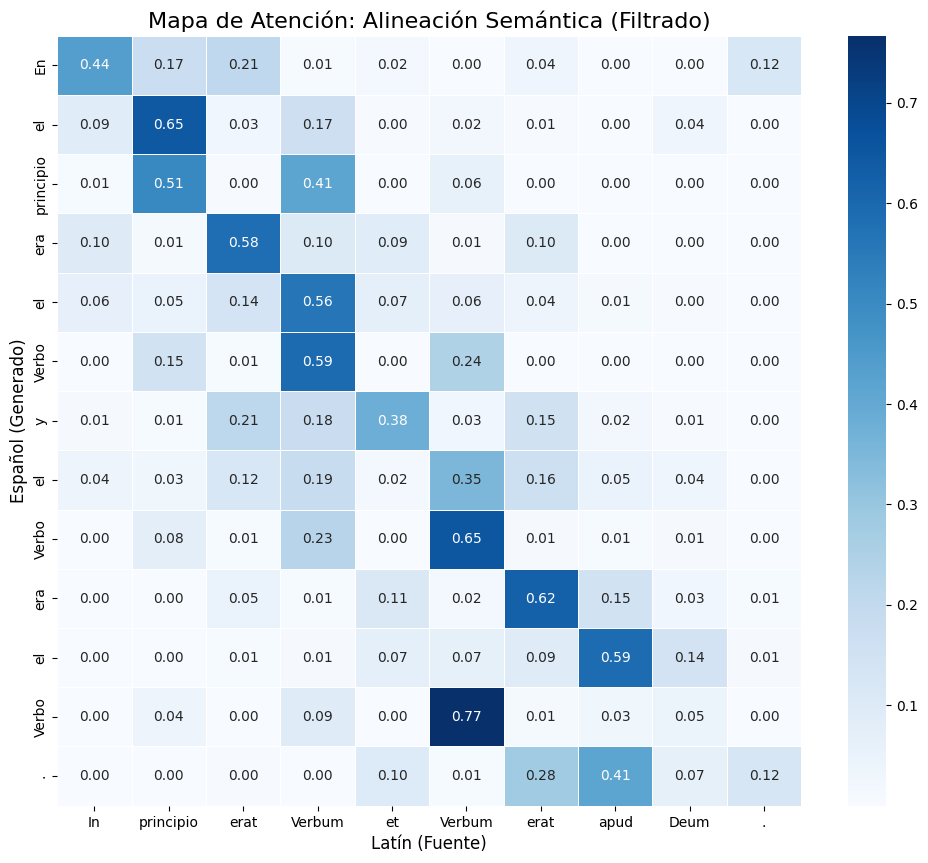

In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def graficar_atencion_mejorada(frase_origen):

    modelo_inf.config._attn_implementation = "eager"

    inputs = tokenizador_inf(frase_origen, return_tensors="pt").to(device)

    with torch.no_grad():

        output_gen = modelo_inf.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=40,
            num_beams=1,
            output_attentions=True,
            return_dict_in_generate=True
        )

    tokens_lat = tokenizador_inf.convert_ids_to_tokens(inputs["input_ids"][0])
    tokens_esp = tokenizador_inf.convert_ids_to_tokens(output_gen.sequences[0])

    etiquetas_a_eliminar = ['<pad>', '</s>', '<s>', '<unk>', '[CLS]', '[SEP]', '<bos>', '<eos>']

    def limpiar(tokens):
        return [t.replace('Ġ', '').replace(' ', '') for t in tokens if t not in etiquetas_a_eliminar]

    tokens_lat_clean = limpiar(tokens_lat)
    tokens_esp_clean = limpiar(tokens_esp)

    atenciones = output_gen.cross_attentions

    matriz = np.zeros((len(tokens_esp_clean), len(tokens_lat_clean)))

    for i in range(min(len(atenciones), len(tokens_esp_clean))):
        pesos = atenciones[i][-1].mean(dim=1).squeeze(0).cpu().numpy()

        fila = pesos[-1] if pesos.ndim > 1 else pesos
        matriz[i, :len(fila)] = fila[:len(matriz[i])]

    plt.figure(figsize=(12, 10))
    sns.heatmap(matriz,
                xticklabels=tokens_lat_clean,
                yticklabels=tokens_esp_clean,
                cmap="Blues",
                annot=True, fmt=".2f", linewidths=.5)

    plt.title('Mapa de Atención: Alineación Semántica (Filtrado)', fontsize=16)
    plt.xlabel('Latín (Fuente)', fontsize=12)
    plt.ylabel('Español (Generado)', fontsize=12)
    plt.show()

graficar_atencion_mejorada("In principio erat Verbum et Verbum erat apud Deum.")